In [1]:
import pandas as pd
import numpy as np

import pickle
import tenseal as ts

import random

import matplotlib.pyplot as plt

In [2]:
with open(
    "../Outputs/Notebook_06/context.pkl",
    "rb"
) as f:

    context_bytes = pickle.load(f)

context = ts.context_from(
    context_bytes
)

print(
    "CKKS Context Loaded"
)

CKKS Context Loaded


In [3]:
with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "rb"
) as f:

    encrypted_embeddings = pickle.load(f)

print(
    len(encrypted_embeddings)
)

7172


In [4]:
compressed_df = pd.read_csv(
    "../Outputs/Notebook_05/compressed_embeddings_with_image.csv"
)

print(
    compressed_df.shape
)

compressed_df.head()

(7172, 129)


,Image,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,S5000L01.jpg,3.531609,0.898729,-0.058201,0.330044,-0.303760,-0.722585,-0.601727,0.072314,0.705561,...,0.107338,-0.193986,0.027331,-0.130831,0.018425,0.581684,-0.414573,-0.044857,-0.199904,0.208726
1,S5000L02.jpg,-1.753484,0.694797,0.776843,0.329095,1.147833,-0.805879,-0.087761,0.579917,0.575204,...,-0.320705,0.058707,-0.095574,-0.280532,0.177044,0.184250,-0.185784,-0.328002,-0.043666,-0.118282
2,S5000L04.jpg,-7.913714,-2.859375,0.189296,0.797377,1.579556,-1.382696,1.545033,0.598341,-0.528655,...,-0.276812,-0.066436,-0.122301,-0.093809,0.118693,-0.138387,0.183409,-0.315280,0.254019,-0.060111
3,S5000L05.jpg,-0.396454,1.704842,-0.851927,1.142179,1.633567,-0.495593,0.709069,-1.764951,0.306490,...,0.248949,-0.143811,-0.195548,-0.613245,-0.110070,0.123135,0.136098,0.230177,-0.171927,0.155451
4,S5000L08.jpg,0.046060,1.989176,0.083279,2.678682,1.089091,-1.016482,1.215376,-2.111116,-0.783882,...,-0.115397,-0.229442,-0.048228,-0.052100,0.144097,0.276113,-0.307274,0.215110,0.044921,0.148986


In [5]:
compressed_df["Label"] = compressed_df[
    "Image"
].str.extract(
    r"(S\d+)"
)

print(
    compressed_df["Label"].nunique()
)

compressed_df[
    ["Image","Label"]
].head()

1000


C:\Users\kumar\AppData\Local\Temp\ipykernel_5600\1296452448.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  compressed_df["Label"] = compressed_df[


,Image,Label
0,S5000L01.jpg,S5000
1,S5000L02.jpg,S5000
2,S5000L04.jpg,S5000
3,S5000L05.jpg,S5000
4,S5000L08.jpg,S5000


In [6]:
compressed_df = pd.read_csv(
    "../Outputs/Notebook_05/compressed_embeddings_with_image.csv"
)

compressed_df["Eye"] = compressed_df["Image"].str.extract(r"(L|R)")

print(compressed_df["Eye"].value_counts())

Eye
L    7172
Name: count, dtype: int64


C:\Users\kumar\AppData\Local\Temp\ipykernel_5600\1920771936.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  compressed_df["Eye"] = compressed_df["Image"].str.extract(r"(L|R)")


In [8]:
compressed_df["Label"] = (
    compressed_df["Image"]
    .str.extract(r"(S\d+)")[0]
)

print(compressed_df[["Image", "Label"]].head())

          Image  Label
0  S5000L01.jpg  S5000
1  S5000L02.jpg  S5000
2  S5000L04.jpg  S5000
3  S5000L05.jpg  S5000
4  S5000L08.jpg  S5000


C:\Users\kumar\AppData\Local\Temp\ipykernel_5600\4205093382.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  compressed_df["Label"] = (


In [9]:
genuine_pairs = []

persons = compressed_df[
    "Label"
].unique()

for person in persons:

    person_rows = compressed_df[
        compressed_df["Label"] == person
    ].index.tolist()

    if len(person_rows) >= 2:

        genuine_pairs.append(

            (
                person_rows[0],
                person_rows[1]
            )

        )

print(
    len(genuine_pairs)
)

1000


In [10]:
impostor_pairs = []

for _ in range(
    len(genuine_pairs)
):

    p1, p2 = random.sample(
        list(persons),
        2
    )

    idx1 = compressed_df[
        compressed_df["Label"] == p1
    ].index[0]

    idx2 = compressed_df[
        compressed_df["Label"] == p2
    ].index[0]

    impostor_pairs.append(
        (
            idx1,
            idx2
        )
    )

print(
    len(impostor_pairs)
)

1000


In [11]:
print(
    type(
        encrypted_embeddings
    )
)

print(
    len(
        encrypted_embeddings
    )
)

print(
    type(
        encrypted_embeddings[0]
    )
)

<class 'list'>
7172
<class 'bytes'>


In [12]:
encrypted_vectors = []

for enc in encrypted_embeddings:

    encrypted_vectors.append(

        ts.ckks_vector_from(
            context,
            enc
        )

    )

print(
    "Encrypted Vectors Loaded"
)

print(
    len(
        encrypted_vectors
    )
)

Encrypted Vectors Loaded
7172


In [13]:
sample = encrypted_vectors[0]

decrypted = sample.decrypt()

print(
    len(decrypted)
)

print(
    decrypted[:5]
)

128
[0.5045524575920115, 0.1283993239453756, -0.008315040032400734, 0.04715252373321862, -0.04339745027571206]


In [14]:
print(
    "Compressed CSV Shape:"
)

print(
    compressed_df.shape
)

print(
    "Feature Columns:"
)

print(
    len(
        compressed_df.columns[1:]
    )
)

print(
    "Decrypted Length:"
)

print(
    len(
        encrypted_vectors[0].decrypt()
    )
)

Compressed CSV Shape:
(7172, 131)
Feature Columns:
130
Decrypted Length:
128


In [15]:
def encrypted_similarity(enc_vec1, enc_vec2):

    result = enc_vec1.dot(enc_vec2)

    return result.decrypt()[0]

In [16]:
genuine_scores = []

for idx1, idx2 in genuine_pairs:

    score = encrypted_similarity(

        encrypted_vectors[idx1],
        encrypted_vectors[idx2]

    )

    genuine_scores.append(score)

print(
    "Average Genuine Score:",
    np.mean(genuine_scores)
)

Average Genuine Score: 0.32788110274803284


In [17]:
impostor_scores = []

for idx1, idx2 in impostor_pairs:

    score = encrypted_similarity(

        encrypted_vectors[idx1],
        encrypted_vectors[idx2]

    )

    impostor_scores.append(score)

print(
    "Average Impostor Score:",
    np.mean(impostor_scores)
)

Average Impostor Score: 0.0035622413664079602


In [18]:
print("Genuine Min :", np.min(genuine_scores))
print("Genuine Max :", np.max(genuine_scores))

print("Impostor Min :", np.min(impostor_scores))
print("Impostor Max :", np.max(impostor_scores))

Genuine Min : -0.5548605125526903
Genuine Max : 0.9999895489662092
Impostor Min : -0.6262643080412128
Impostor Max : 0.7088431055101166


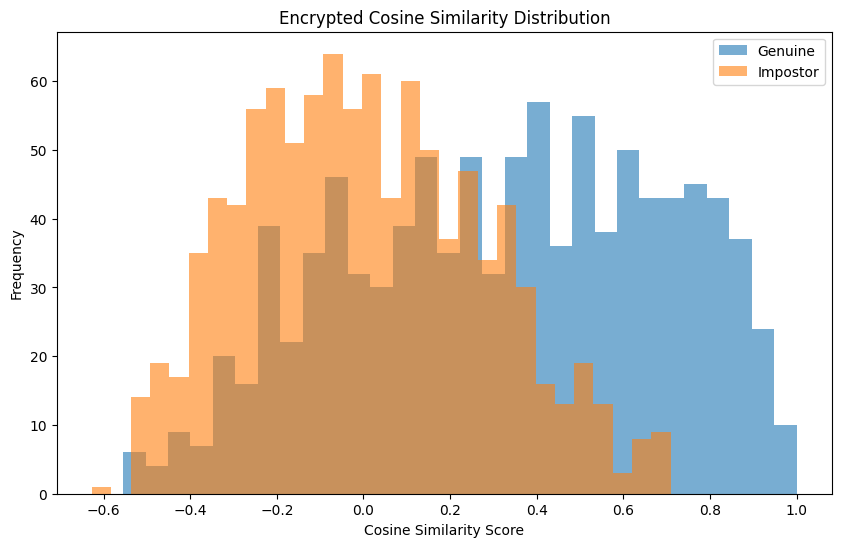

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    genuine_scores,
    bins=30,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    impostor_scores,
    bins=30,
    alpha=0.6,
    label="Impostor"
)

plt.xlabel("Cosine Similarity Score")
plt.ylabel("Frequency")
plt.title("Encrypted Cosine Similarity Distribution")

plt.legend()

plt.savefig(
    "../Outputs/Notebook_07/similarity_distribution.png"
)

plt.show()

In [20]:
threshold = (
    np.mean(genuine_scores)
    +
    np.mean(impostor_scores)
) / 2

print(
    "Threshold:",
    threshold
)

Threshold: 0.1657216720572204


In [21]:
genuine_correct = sum(

    score > threshold

    for score in genuine_scores

)

impostor_correct = sum(

    score < threshold

    for score in impostor_scores

)

total = len(genuine_scores) + len(impostor_scores)

accuracy = (

    genuine_correct
    +
    impostor_correct

) / total * 100

print(
    "Genuine Correct:",
    genuine_correct
)

print(
    "Impostor Correct:",
    impostor_correct
)

print(
    "Authentication Accuracy:",
    accuracy
)

Genuine Correct: 650
Impostor Correct: 717
Authentication Accuracy: 68.35


In [22]:
results_df = pd.DataFrame({

    "Metric": [

        "Average Genuine Score",
        "Average Impostor Score",
        "Threshold",
        "Authentication Accuracy"

    ],

    "Value": [

        np.mean(genuine_scores),
        np.mean(impostor_scores),
        threshold,
        accuracy

    ]

})

results_df.to_csv(

    "../Outputs/Notebook_07/authentication_results.csv",

    index=False

)

print(
    "Results Saved Successfully"
)

Results Saved Successfully


In [23]:
genuine_df = pd.DataFrame({
    "Genuine_Score": genuine_scores
})

genuine_df.to_csv(
    "../Outputs/Notebook_07/genuine_scores.csv",
    index=False
)

print("Genuine scores saved successfully.")

Genuine scores saved successfully.


In [24]:
impostor_df = pd.DataFrame({
    "Impostor_Score": impostor_scores
})

impostor_df.to_csv(
    "../Outputs/Notebook_07/impostor_scores.csv",
    index=False
)

print("Impostor scores saved successfully.")

Impostor scores saved successfully.


In [25]:
threshold_df = pd.DataFrame({
    "Threshold": [threshold]
})

threshold_df.to_csv(
    "../Outputs/Notebook_07/threshold.csv",
    index=False
)

print("Threshold Saved Successfully")
print("Threshold =", threshold)

Threshold Saved Successfully
Threshold = 0.1657216720572204
